# Customer Churn — Data Visualization

## Project Objective

The goal of this notebook is to visualize the customer churn patterns
found during the exploratory data analysis.

The visualizations help make the patterns easier to understand and compare
across different customer groups.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv(r"Telco-Customer-Churn.csv")

In [5]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Overall Customer Churn

First, we look at the overall distribution of customers who churned and
customers who stayed.

In [7]:
plt.style.use('dark_background')

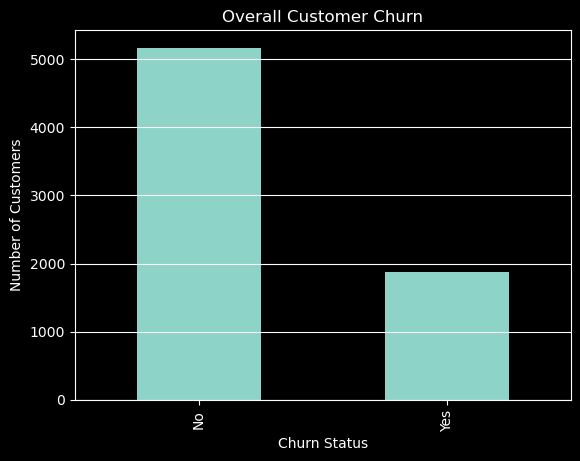

In [8]:
churn_counts = data['Churn'].value_counts()

churn_counts.plot(kind='bar')

plt.title('Overall Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.grid(axis='y')

### 2. Churn Rate by Contract Type

The churn rate is compared across different contract types to see which
type of contract has a higher churn rate.

In [12]:
contract_churned = data.loc[data['Churn'] == 'Yes'].groupby('Contract')['customerID'].count()
contract_total = data.groupby('Contract')['customerID'].count()

contract_churn_rate = contract_churned / contract_total * 100

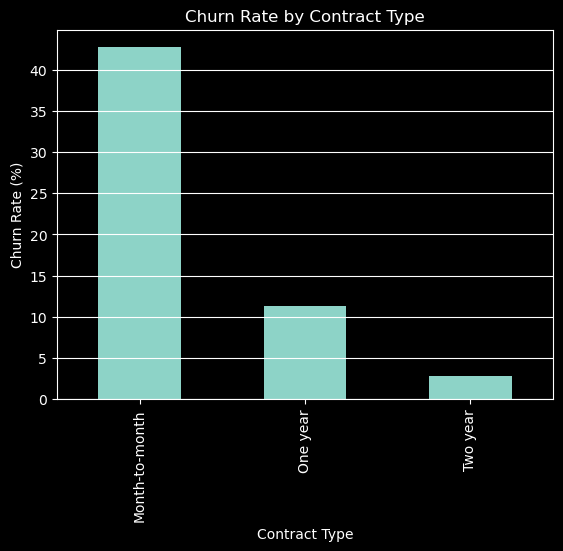

In [13]:
contract_churn_rate.plot(kind = 'bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')

### 3. Churn Rate by Payment Method

The churn rate is compared across different payment methods to see if
there are differences in customer churn.

In [14]:
payment_churned = data.loc[data['Churn'] == 'Yes'].groupby('PaymentMethod')['customerID'].count()
payment_total = data.groupby('PaymentMethod')['customerID'].count()

payment_churn_rate = payment_churned / payment_total * 100

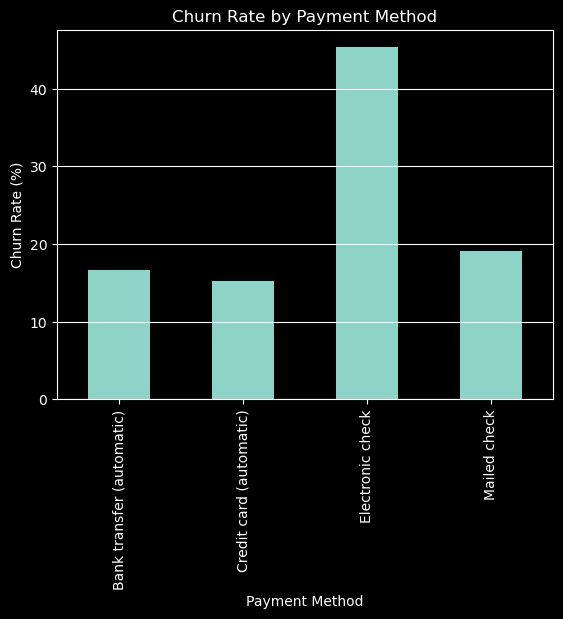

In [15]:
payment_churn_rate.plot(kind = 'bar')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')

### 4. Churn Rate by Internet Service

The churn rate is compared across different internet service types to see
if customer churn is different between the groups.

In [16]:
internet_churned = data[data['Churn'] == 'Yes'].groupby('InternetService')['customerID'].count()
internet_total = data.groupby('InternetService')['customerID'].count()

internet_churn_rate = internet_churned / internet_total * 100

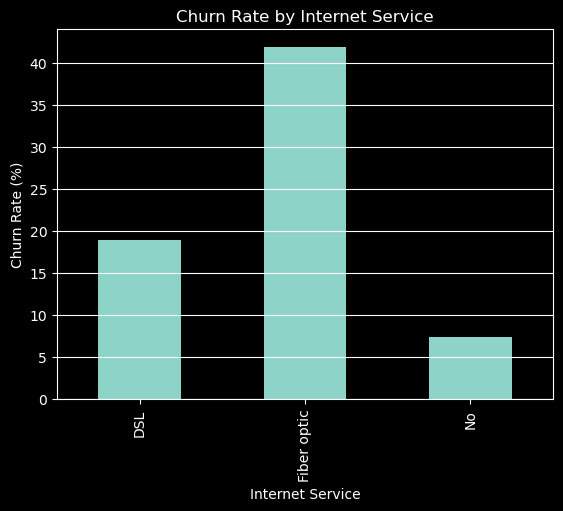

In [17]:
internet_churn_rate.plot(kind = 'bar')

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')

### 5. Churn Rate by Tenure Group

The churn rate is compared between customers with less than 12 months of
tenure and customers with 12 months or more of tenure.

In [18]:
tenure_churned = data[data['Churn'] == 'Yes'].groupby(
    data['tenure'] < 12
)['customerID'].count()

tenure_total = data.groupby(
    data['tenure'] < 12
)['customerID'].count()

tenure_churn_rate = tenure_churned / tenure_total * 100

tenure_churn_rate

tenure
False    17.490953
True     48.284195
Name: customerID, dtype: float64

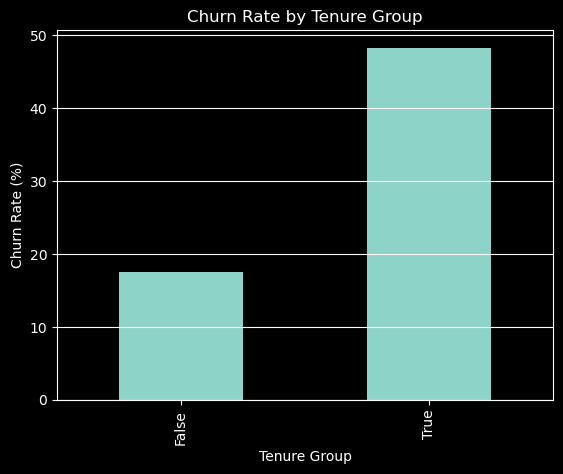

In [19]:
tenure_churn_rate.plot(kind='bar')

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')

### 6. Churn Rate by Monthly Charges

Monthly charges are divided into three groups to compare the churn rate
at different charge levels.

The groups are:
- Less than 50
- 50 to less than 100
- 100 or more

In [24]:
monthly_churned_less_50 = data.loc[(data['Churn'] == 'Yes') & (data['MonthlyCharges'] < 50)]['customerID'].count()
monthly_total_less_50 = data.loc[data['MonthlyCharges'] < 50]['customerID'].count()

monthly_churn_rate_less_50 = (monthly_churned_less_50 / monthly_total_less_50) * 100
monthly_churn_rate_less_50

np.float64(15.736704446381866)

In [25]:
monthly_churned_50_100 = data.loc[(data['Churn'] == 'Yes') & (data['MonthlyCharges'] >= 50) &(data['MonthlyCharges'] < 100)
                         ]['customerID'].count()

monthly_total_50_100 = data.loc[(data['MonthlyCharges'] >= 50) & (data['MonthlyCharges'] < 100)]['customerID'].count()

monthly_churn_rate_50_100 = (monthly_churned_50_100 / monthly_total_50_100) * 100

monthly_churn_rate_50_100


np.float64(32.56964332205155)

In [27]:
monthly_churned_100_plus = data.loc[(data['Churn'] == 'Yes') & (data['MonthlyCharges'] >= 100)]['customerID'].count()

monthly_total_100_plus = data.loc[data['MonthlyCharges'] >= 100]['customerID'].count()

monthly_churn_rate_100_plus = (monthly_churned_100_plus / monthly_total_100_plus) * 100

monthly_churn_rate_100_plus

np.float64(28.30396475770925)

In [28]:
monthly_churn_rate = pd.Series({
    'Less than 50': monthly_churn_rate_less_50,
    '50 to less than 100': monthly_churn_rate_50_100,
    '100 or more': monthly_churn_rate_100_plus
})

monthly_churn_rate

Less than 50           15.736704
50 to less than 100    32.569643
100 or more            28.303965
dtype: float64

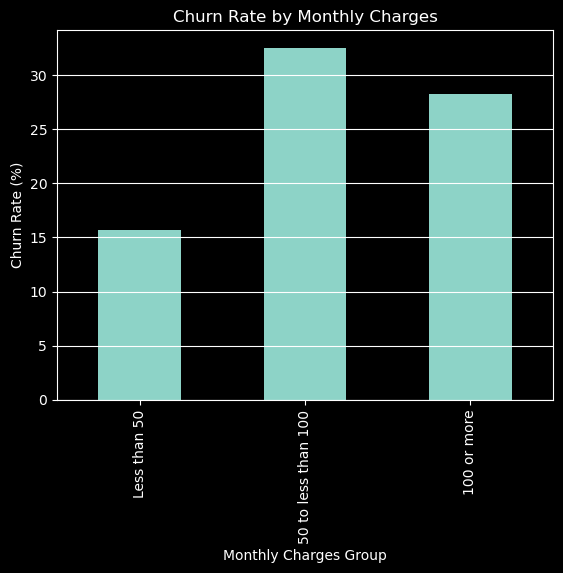

In [29]:
monthly_churn_rate.plot(kind = 'bar')

plt.title('Churn Rate by Monthly Charges')
plt.xlabel('Monthly Charges Group')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')

### 7. Churn Rate by Senior Citizen Status

The churn rate is compared between senior citizens and non-senior customers
to see if there is a difference in customer churn.

In [30]:
senior_churned = data[data['Churn'] == 'Yes'].groupby(
    'SeniorCitizen'
)['customerID'].count()

senior_total = data.groupby(
    'SeniorCitizen'
)['customerID'].count()

senior_churn_rate = senior_churned / senior_total * 100

senior_churn_rate

SeniorCitizen
0    23.606168
1    41.681261
Name: customerID, dtype: float64

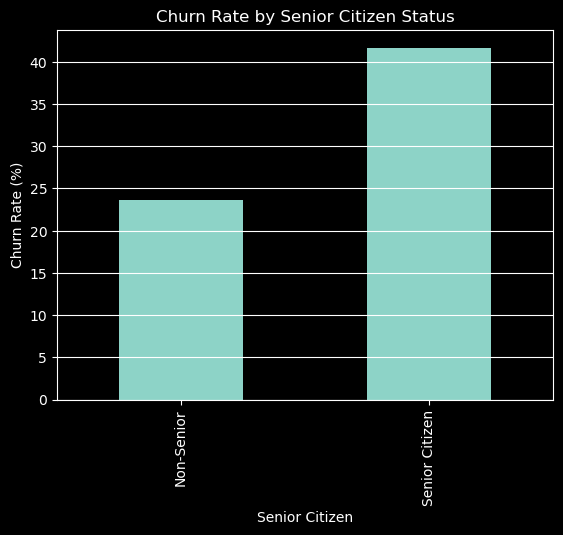

In [32]:
senior_churn_rate.plot(kind = 'bar')

plt.xticks([0, 1], ['Non-Senior', 'Senior Citizen'])
plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')

### 8. Churn Rate by Partner Status

The churn rate is compared between customers with and without a partner
to see if there is a difference in customer churn.

In [33]:
partner_churned = data[data['Churn'] == 'Yes'].groupby(
    'Partner'
)['customerID'].count()

partner_total = data.groupby(
    'Partner'
)['customerID'].count()

partner_churn_rate = partner_churned / partner_total * 100

partner_churn_rate

Partner
No     32.957979
Yes    19.664903
Name: customerID, dtype: float64

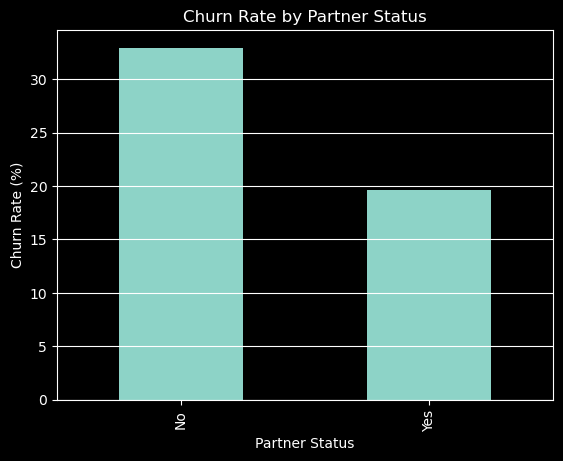

In [34]:
partner_churn_rate.plot(kind = 'bar')

plt.title('Churn Rate by Partner Status')
plt.xlabel('Partner Status')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')

### 9. Churn Rate by Dependents Status

The churn rate is compared between customers with and without dependents
to see if there is a difference in customer churn.

In [35]:
dependents_churned = data[data['Churn'] == 'Yes'].groupby(
    'Dependents'
)['customerID'].count()

dependents_total = data.groupby(
    'Dependents'
)['customerID'].count()

dependents_churn_rate = dependents_churned / dependents_total * 100

dependents_churn_rate

Dependents
No     31.279140
Yes    15.450237
Name: customerID, dtype: float64

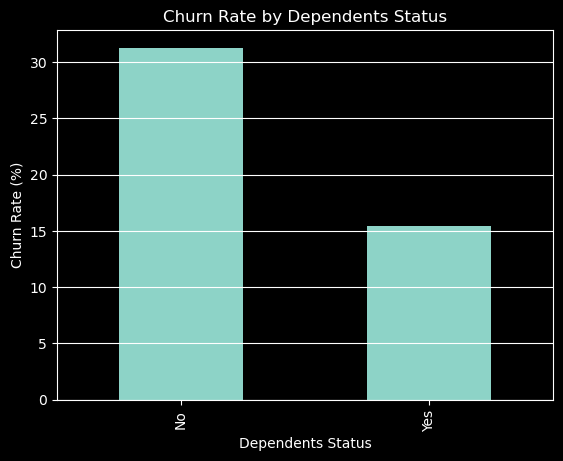

In [36]:
dependents_churn_rate.plot(kind = 'bar')

plt.title('Churn Rate by Dependents Status')
plt.xlabel('Dependents Status')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')

### Visualization Summary

The visualizations show that churn is not the same across all customer
groups.

The biggest differences can be seen in tenure, contract type, payment
method, internet service, and monthly charges. Customers with less than
12 months of tenure, month-to-month contracts, electronic check payments,
and fiber optic internet have higher churn rates.

We also see higher churn among senior citizens and customers who do not
have a partner or dependents.

These patterns help us understand which customer groups are more likely
to churn and give us a better idea of the factors that may be related to
customer churn.

## 7. Key Findings

The analysis shows some clear patterns in customer churn.

- Customers with less than 12 months of tenure have a much higher churn rate.
- Month-to-month contract customers are more likely to churn than customers with longer contracts.
- Electronic check users have a higher churn rate compared to other payment methods.
- Fiber optic customers have a higher churn rate than DSL and customers without internet service.
- Customers with higher monthly charges also show higher churn in some charge groups.
- Senior citizens and customers without partners or dependents have higher churn rates in this dataset.

These findings show that customer tenure, contract type, payment method, and
internet service are some of the important factors related to churn.

## 8. Conclusion

This analysis helped me understand the main patterns in customer churn.

Customers with low tenure, month-to-month contracts, electronic check
payments, and fiber optic internet showed higher churn rates in the dataset.

The analysis also showed differences based on monthly charges, senior
citizen status, partner status, and dependents.

These findings can be useful for understanding customer behavior and can
also provide a good starting point for building a machine learning model
to predict customer churn in the future.